In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

Зашумить изображение

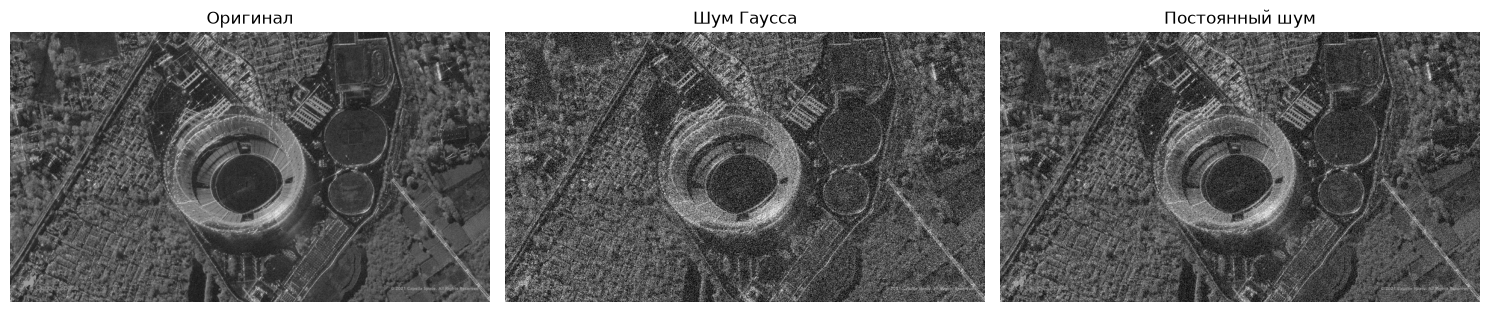

In [14]:
image = cv2.imread('sar_1.jpg', cv2.IMREAD_GRAYSCALE)

mean, stddev = 0, 50
noise_gauss = np.zeros(image.shape, np.float32)
cv2.randn(noise_gauss, mean, stddev)
noise_gauss_image = np.clip(
    image.astype(np.float32) + noise_gauss, 0, 255
).astype(np.uint8)

low, high = -50, 50
noise_uniform = np.random.uniform(low, high, image.shape).astype(np.float32)
noise_uniform_image = np.clip(
    image.astype(np.float32) + noise_uniform, 0, 255
).astype(np.uint8)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(image, cmap='gray'); plt.title('Оригинал'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(noise_gauss_image, cmap='gray'); plt.title('Шум Гаусса'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(noise_uniform_image, cmap='gray'); plt.title('Постоянный шум'); plt.axis('off')
plt.tight_layout()
plt.show()

Тест фильтров для шума Гаусса

Результаты:
Гаусса 3x3 сигма 0: MSE=376.73, SSIM=0.5186
Гаусса 5x5 сигма 0: MSE=283.50, SSIM=0.5622
Гаусса 7x7 сигма 0: MSE=263.22, SSIM=0.5598
Гаусса 3x3 сигма 1: MSE=355.09, SSIM=0.5270
Гаусса 5x5 сигма 1: MSE=291.77, SSIM=0.5594
Гаусса 7x7 сигма 1: MSE=287.51, SSIM=0.5613
Гаусса 3x3 сигма 2: MSE=345.15, SSIM=0.5209
Гаусса 5x5 сигма 2: MSE=276.94, SSIM=0.5393
Гаусса 7x7 сигма 2: MSE=277.62, SSIM=0.5264
Медианный 3x3: MSE=523.14, SSIM=0.4312
Медианный 5x5: MSE=359.23, SSIM=0.4546
Медианный 7x7: MSE=348.29, SSIM=0.4264
Билатериальный d=9 сигма 25: MSE=1540.56, SSIM=0.2657
Билатериальный d=9 сигма 75: MSE=402.71, SSIM=0.4607
Билатериальный d=15 сигма 100: MSE=355.24, SSIM=0.4434
Нелокальных средних h=10: MSE=2137.54, SSIM=0.2292
Нелокальных средних h=20: MSE=2104.51, SSIM=0.2309
Нелокальных средних h=30: MSE=581.75, SSIM=0.4218


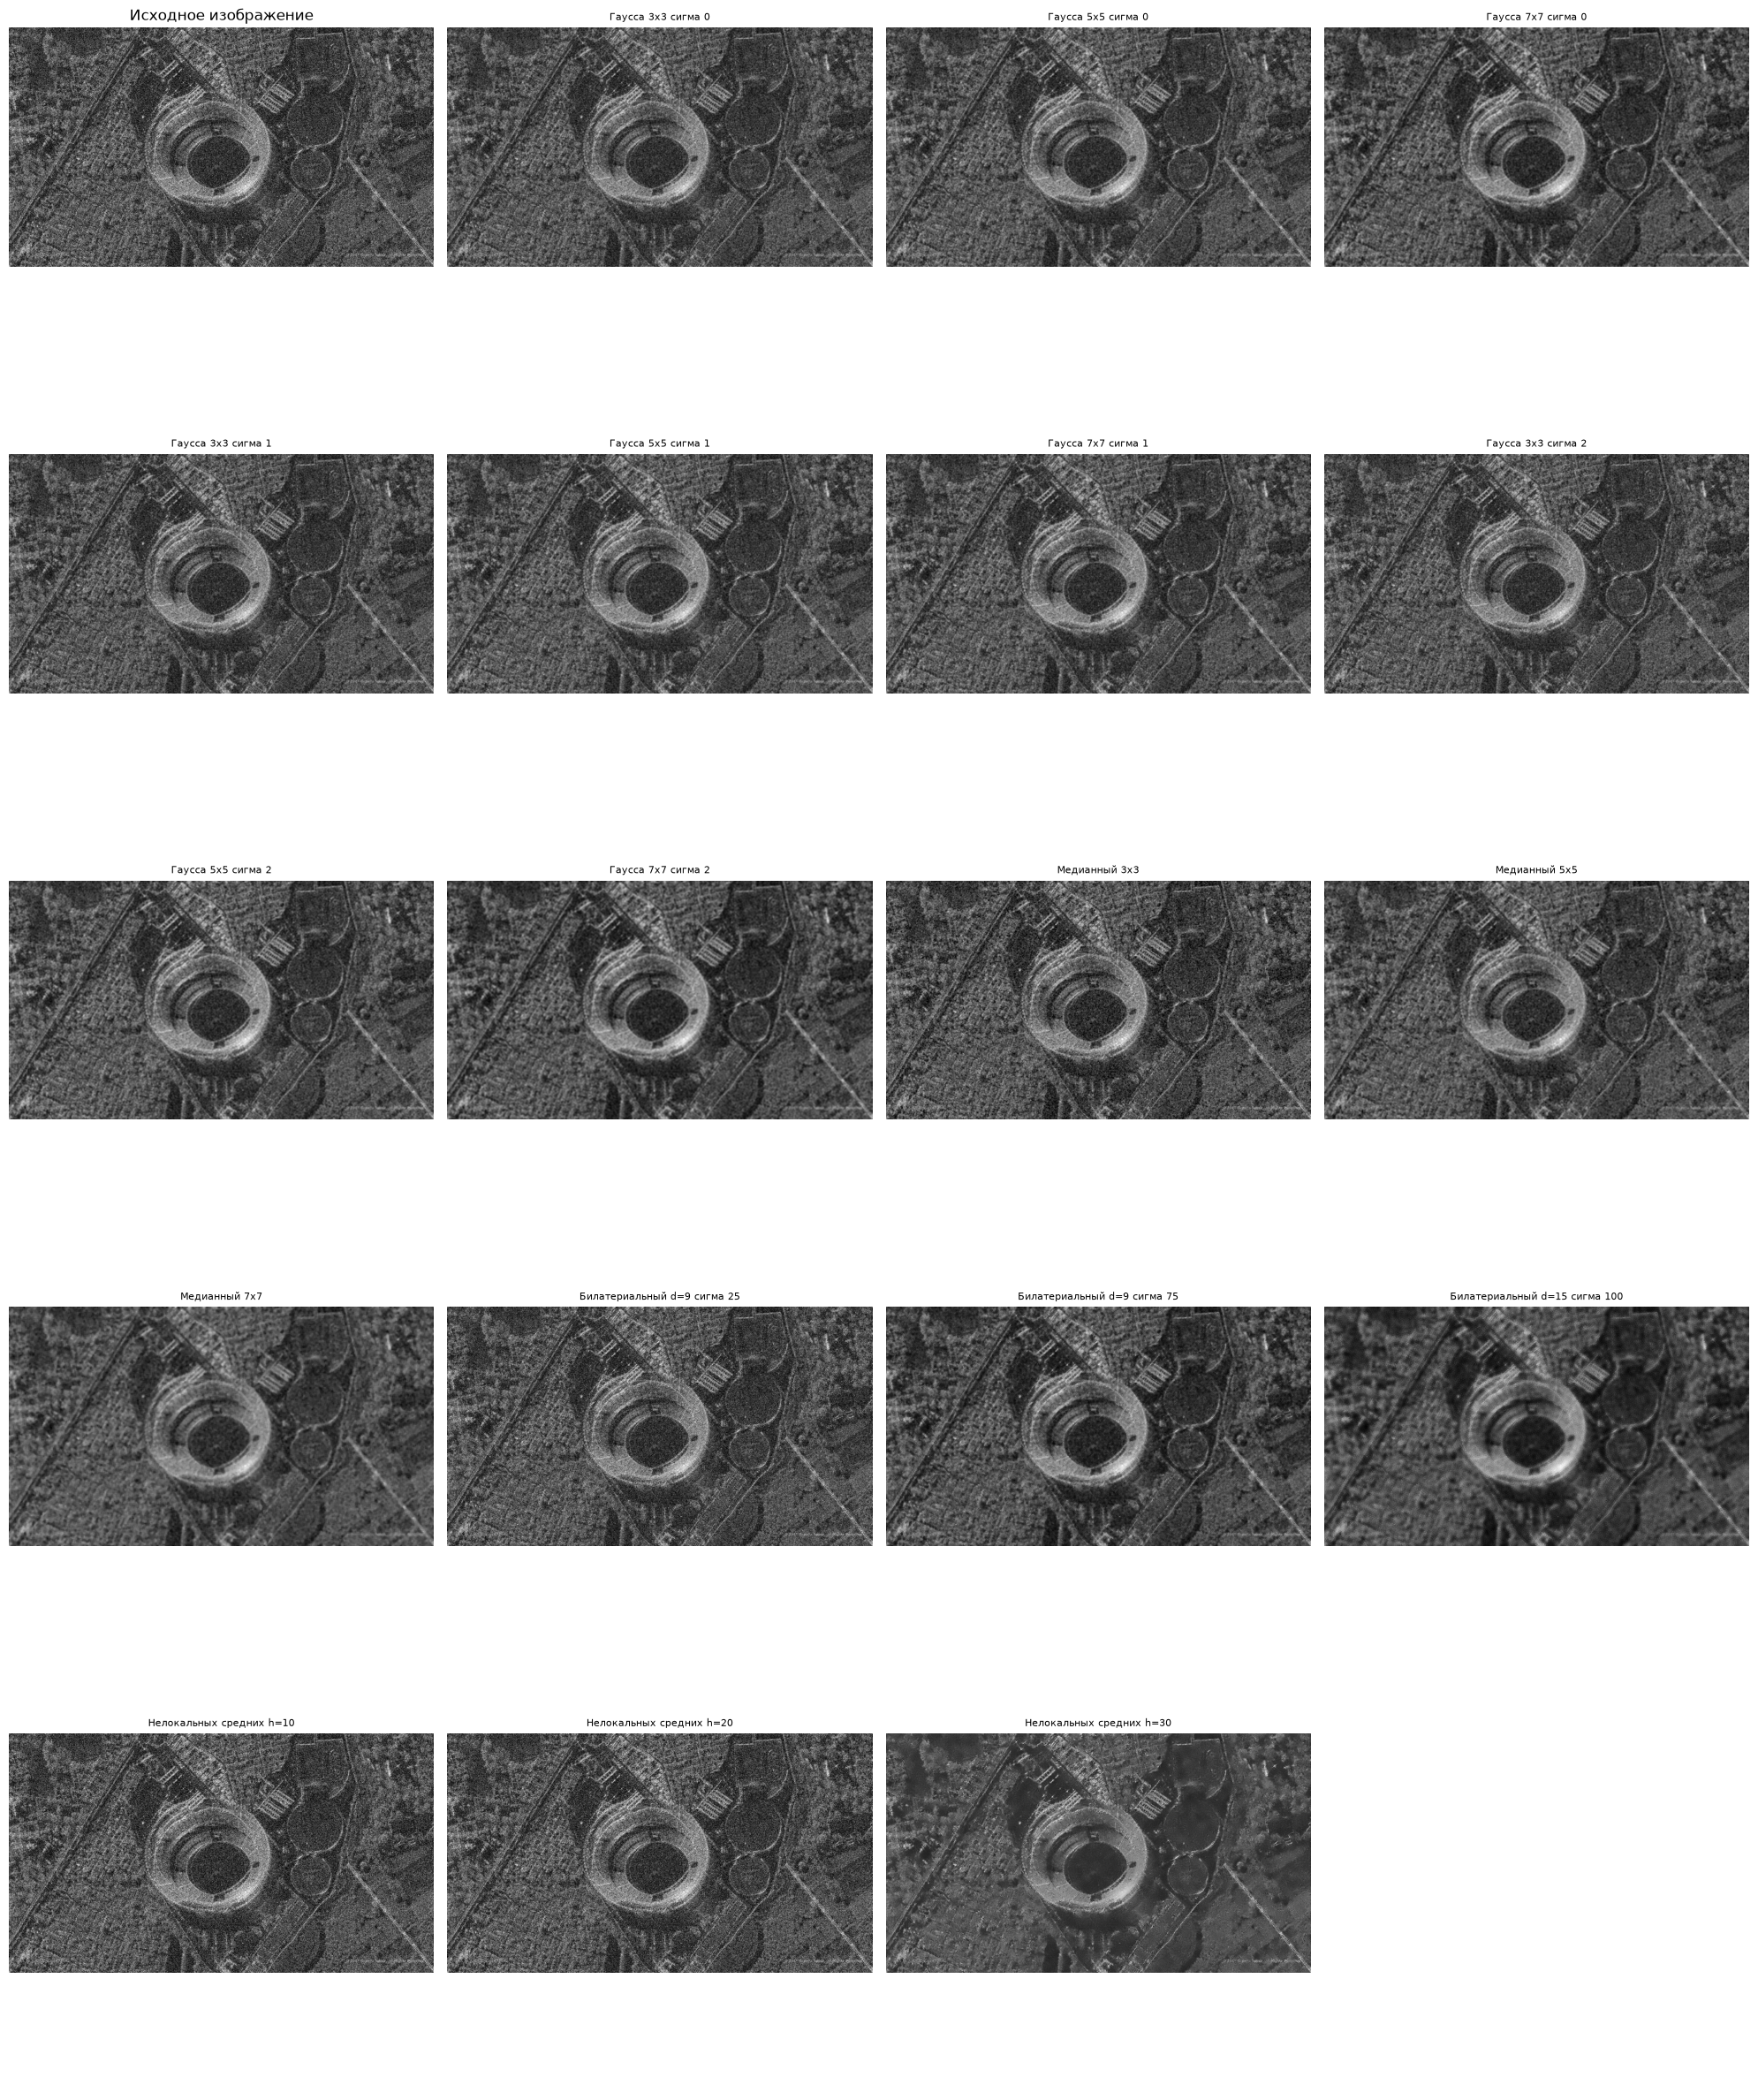

In [10]:
def filter_test(noisy_image, clean_image):
    filters_to_test = [
        ('Гаусса 3x3 сигма 0', cv2.GaussianBlur(noisy_image, (3, 3), 0)),
        ('Гаусса 5x5 сигма 0', cv2.GaussianBlur(noisy_image, (5, 5), 0)),
        ('Гаусса 7x7 сигма 0', cv2.GaussianBlur(noisy_image, (7, 7), 0)),
        ('Гаусса 3x3 сигма 1', cv2.GaussianBlur(noisy_image, (3, 3), 1)),
        ('Гаусса 5x5 сигма 1', cv2.GaussianBlur(noisy_image, (5, 5), 1)),
        ('Гаусса 7x7 сигма 1', cv2.GaussianBlur(noisy_image, (7, 7), 1)),
        ('Гаусса 3x3 сигма 2', cv2.GaussianBlur(noisy_image, (3, 3), 2)),
        ('Гаусса 5x5 сигма 2', cv2.GaussianBlur(noisy_image, (5, 5), 2)),
        ('Гаусса 7x7 сигма 2', cv2.GaussianBlur(noisy_image, (7, 7), 2)),
        
        ('Медианный 3x3', cv2.medianBlur(noisy_image, 3)),
        ('Медианный 5x5', cv2.medianBlur(noisy_image, 5)),
        ('Медианный 7x7', cv2.medianBlur(noisy_image, 7)),
        
        ('Билатериальный d=9 сигма 25', cv2.bilateralFilter(noisy_image, 9, 25, 25)),
        ('Билатериальный d=9 сигма 75', cv2.bilateralFilter(noisy_image, 9, 75, 75)),
        ('Билатериальный d=15 сигма 100', cv2.bilateralFilter(noisy_image, 15, 100, 100)),
        
        ('Нелокальных средних h=10', cv2.fastNlMeansDenoising(noisy_image, None, 10)),
        ('Нелокальных средних h=20', cv2.fastNlMeansDenoising(noisy_image, None, 20)),
        ('Нелокальных средних h=30', cv2.fastNlMeansDenoising(noisy_image, None, 30))
    ]
    results = {}

    print("Результаты:")
    
    for filter_name, filtered_image in filters_to_test:
        mse = mean_squared_error(clean_image, filtered_image)
        ssim = structural_similarity(clean_image, filtered_image)
        
        print(f"{filter_name}: MSE={mse:.2f}, SSIM={ssim:.4f}")
        
        results[filter_name] = {
            'image': filtered_image,
            'mse': mse,
            'ssim': ssim
        }
    return results

def visualize(noisy_image, results):
    n_filters = len(results)
    n_cols = 4
    n_rows = (n_filters + n_cols) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = axes.flatten()
    
    axes[0].imshow(noisy_image, cmap='gray')
    axes[0].set_title('Исходное изображение')
    axes[0].axis('off')
    
    for idx, (filter_name, result) in enumerate(results.items(), 1):
        if idx < len(axes):
            axes[idx].imshow(result['image'], cmap='gray')
            axes[idx].set_title(f'{filter_name}', fontsize=8)
            axes[idx].axis('off')
    
    for idx in range(len(results) + 1, len(axes)):
        axes[idx].axis('off')
        
    plt.tight_layout()
    plt.show()

results = filter_test(noise_gauss_image, image)
visualize(noise_gauss_image, results)

Поиск лучшего для шума Гаусса

Лучший фильтр по MSE:
  Название: Гаусса 7x7 сигма 0
  MSE: 263.22
  SSIM: 0.5598

Лучший фильтр по SSIM:
  Название: Гаусса 5x5 сигма 0
  MSE: 283.50
  SSIM: 0.5622


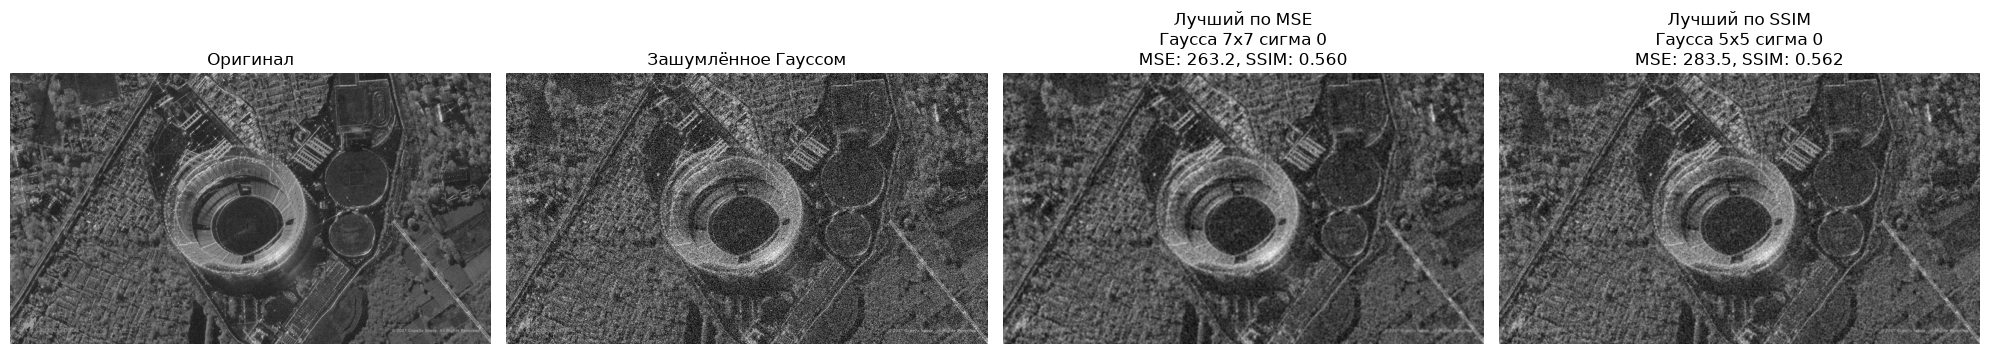

In [11]:
def find_best_filter(results, m):
    best = None
    for name, res in results.items():
        mse, ssim = res['mse'], res['ssim']

        if best is None:
            better = True
        elif m == 'mse':
            better = (mse < best['mse']) or (
                abs(mse - best['mse']) < 1e-9 and ssim > best['ssim']
            )
        else:
            better = (ssim > best['ssim']) or (
                abs(ssim - best['ssim']) < 1e-9 and mse < best['mse']
            )

        if better:
            best = {'name': name, 'mse': mse, 'ssim': ssim}

    return best


best_mse  = find_best_filter(results, 'mse')
best_ssim = find_best_filter(results, 'ssim')

print("Лучший фильтр по MSE:")
print(f"  Название: {best_mse['name']}")
print(f"  MSE: {best_mse['mse']:.2f}")
print(f"  SSIM: {best_mse['ssim']:.4f}")

print("\nЛучший фильтр по SSIM:")
print(f"  Название: {best_ssim['name']}")
print(f"  MSE: {best_ssim['mse']:.2f}")
print(f"  SSIM: {best_ssim['ssim']:.4f}")

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Оригинал')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(noise_gauss_image, cmap='gray')
plt.title('Зашумлённое Гауссом')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(results[best_mse['name']]['image'], cmap='gray')
plt.title(f"Лучший по MSE\n{best_mse['name']}\nMSE: {best_mse['mse']:.1f}, SSIM: {best_mse['ssim']:.3f}")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(results[best_ssim['name']]['image'], cmap='gray')
plt.title(f"Лучший по SSIM\n{best_ssim['name']}\nMSE: {best_ssim['mse']:.1f}, SSIM: {best_ssim['ssim']:.3f}")
plt.axis('off')

plt.tight_layout()
plt.show()

Лучшими показали себя Гаусса 7х7 сигма 0 по MSE и Гаусса 5x5 сигма 0 по SSIM

Тест фильтров для постоянного шума

Результаты:
Гаусса 3x3 сигма 0: MSE=180.66, SSIM=0.6847
Гаусса 5x5 сигма 0: MSE=172.96, SSIM=0.6820
Гаусса 7x7 сигма 0: MSE=197.63, SSIM=0.6352
Гаусса 3x3 сигма 1: MSE=178.36, SSIM=0.6843
Гаусса 5x5 сигма 1: MSE=170.21, SSIM=0.6881
Гаусса 7x7 сигма 1: MSE=170.51, SSIM=0.6869
Гаусса 3x3 сигма 2: MSE=187.07, SSIM=0.6655
Гаусса 5x5 сигма 2: MSE=208.34, SSIM=0.6149
Гаусса 7x7 сигма 2: MSE=230.25, SSIM=0.5763
Медианный 3x3: MSE=311.86, SSIM=0.5422
Медианный 5x5: MSE=284.55, SSIM=0.5080
Медианный 7x7: MSE=310.86, SSIM=0.4524
Билатериальный d=9 сигма 25: MSE=443.71, SSIM=0.5035
Билатериальный d=9 сигма 75: MSE=209.14, SSIM=0.6098
Билатериальный d=15 сигма 100: MSE=304.06, SSIM=0.4734
Нелокальных средних h=10: MSE=823.17, SSIM=0.4156
Нелокальных средних h=20: MSE=283.74, SSIM=0.6125
Нелокальных средних h=30: MSE=249.81, SSIM=0.5239


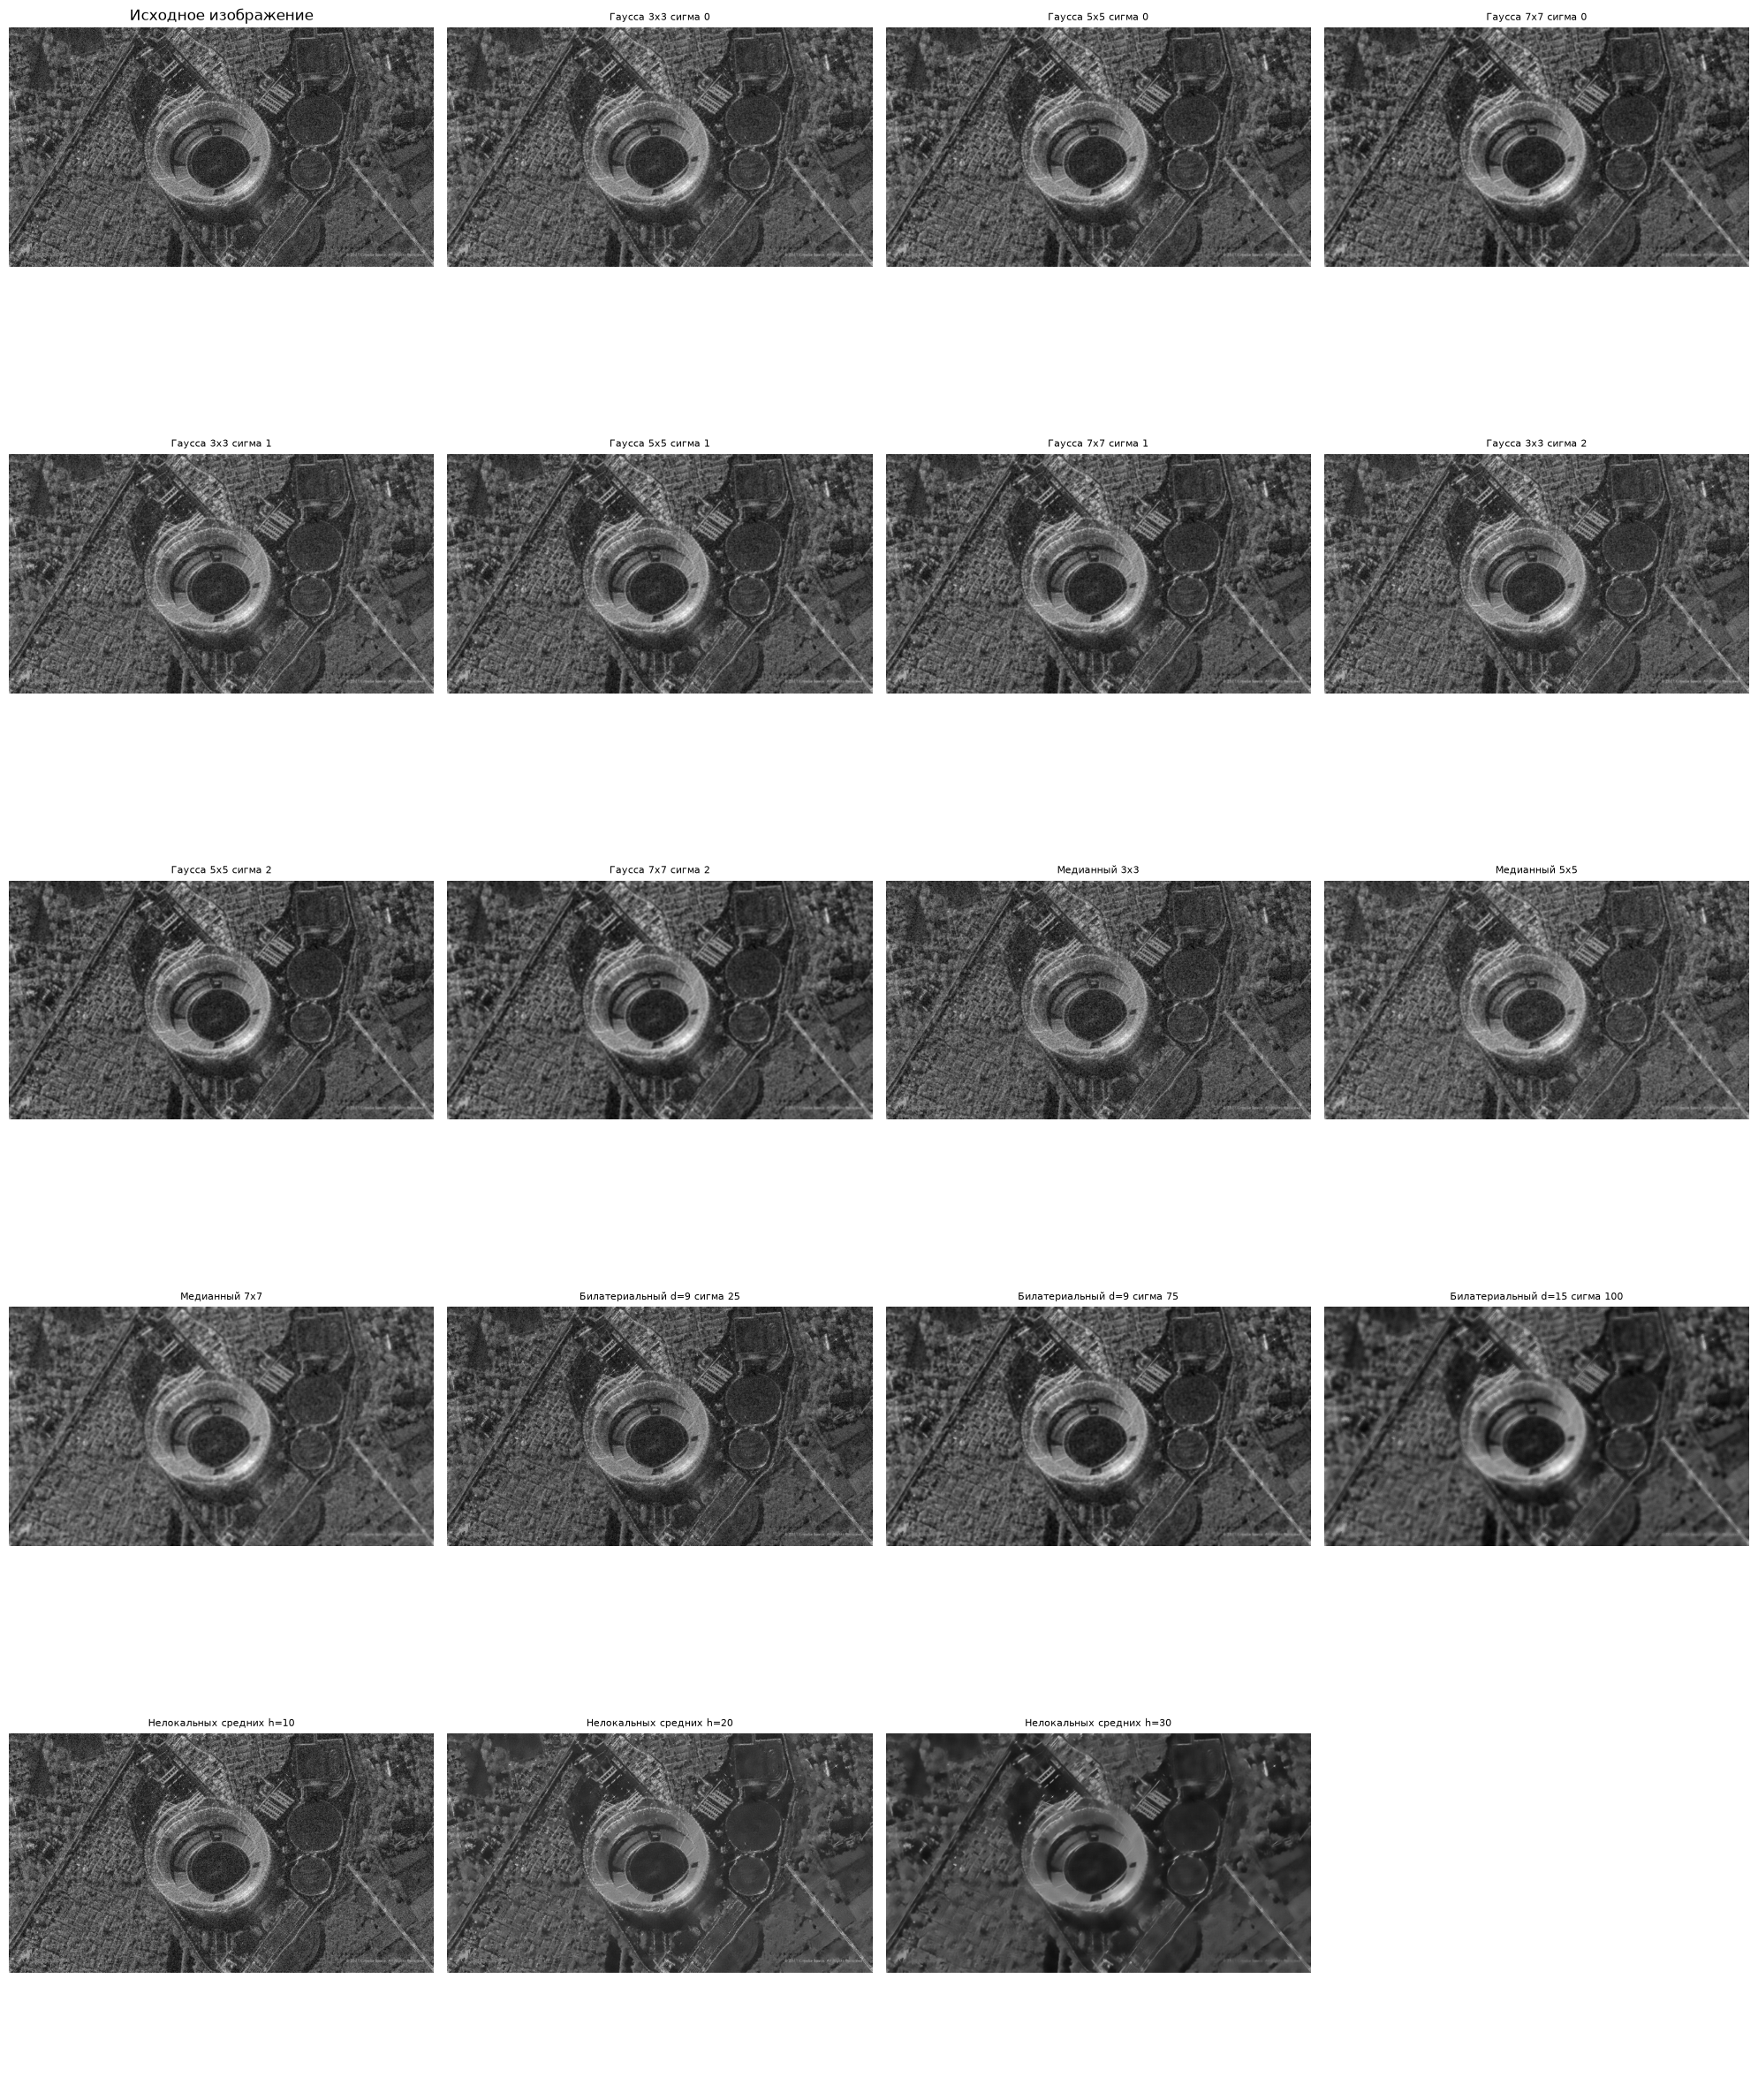

In [12]:
results = filter_test(noise_uniform_image, image)
visualize(noise_uniform_image, results)

Поиск лучшего для постоянного шума

Лучший фильтр по MSE:
  Название: Гаусса 5x5 сигма 1
  MSE: 170.21
  SSIM: 0.6881

Лучший фильтр по SSIM:
  Название: Гаусса 5x5 сигма 1
  MSE: 170.21
  SSIM: 0.6881


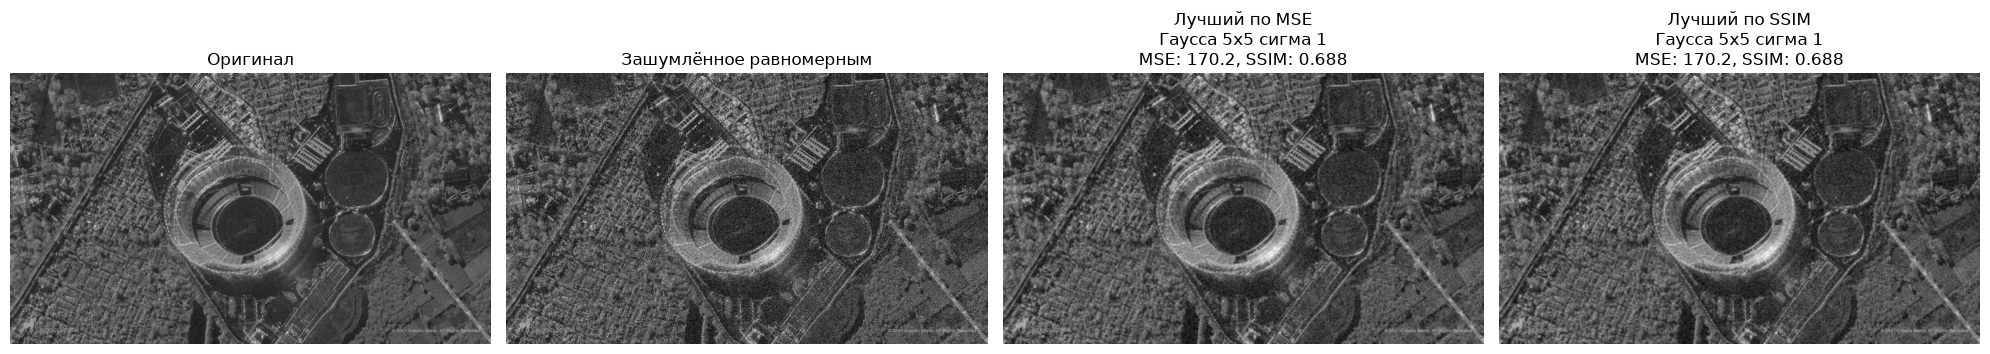

In [15]:
best_mse  = find_best_filter(results, 'mse')
best_ssim = find_best_filter(results, 'ssim')

print("Лучший фильтр по MSE:")
print(f"  Название: {best_mse['name']}")
print(f"  MSE: {best_mse['mse']:.2f}")
print(f"  SSIM: {best_mse['ssim']:.4f}")

print("\nЛучший фильтр по SSIM:")
print(f"  Название: {best_ssim['name']}")
print(f"  MSE: {best_ssim['mse']:.2f}")
print(f"  SSIM: {best_ssim['ssim']:.4f}")

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Оригинал')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(noise_uniform_image, cmap='gray')
plt.title('Зашумлённое равномерным')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(results[best_mse['name']]['image'], cmap='gray')
plt.title(f"Лучший по MSE\n{best_mse['name']}\nMSE: {best_mse['mse']:.1f}, SSIM: {best_mse['ssim']:.3f}")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(results[best_ssim['name']]['image'], cmap='gray')
plt.title(f"Лучший по SSIM\n{best_ssim['name']}\nMSE: {best_ssim['mse']:.1f}, SSIM: {best_ssim['ssim']:.3f}")
plt.axis('off')

plt.tight_layout()
plt.show()

Лучшим показал себя Гаусса 5х5 сигма 1